# Analise Preditiva e Prescritiva - Rede de Varejo Multicanal

## Grupo 7
MARCIO RIBEIRO JULIÃO,
LUCAS PEREIRA CANUTO,
MARCELO FRESCHI DE OLIVEIRA CORREIA MENEZES,
CAIO ACAYABA FURTADO,
GUSTAVO CARDOSO SOUSA.

Objetivo:
- Analise preditiva: prever `valor_total` a partir de `quantidade`, `preco_unitario` e `campanha` com Regressao Linear.
- Analise prescritiva: simular cenarios de quantidade e preco para maximizar lucro previsto.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
data_path = Path("vendas_rede_varejo.csv")

if not data_path.exists():
    candidates = [
        p for p in Path.cwd().rglob("vendas_rede_varejo.csv") if "aula05-14" in str(p)
    ]
    if candidates:
        data_path = candidates[0]
    else:
        raise FileNotFoundError(
            "Arquivo vendas_rede_varejo.csv nao encontrado. Rode o notebook na pasta da atividade."
        )

df = pd.read_csv(data_path, sep=";", decimal=",")

df.head()

,data_venda,canal_venda,regiao,categoria_produto,quantidade,preco_unitario,valor_total,custo_total,campanha,satisfacao_cliente
0,2025-04-13,App,Norte,Eletrodomésticos,16,1318.49,21095.84,11291.56,Natal,6.1
1,2025-12-15,App,Sudeste,Beleza,19,561.28,10664.32,6138.38,Aniversário da Loja,8.1
2,2025-09-28,Loja Física,Sudeste,Moda,14,2473.79,34633.06,26883.11,Black Friday,8.0
3,2025-04-17,E-commerce,Norte,Alimentos,16,1444.60,23113.60,15589.58,Dia das Mães,8.3
4,2025-03-13,E-commerce,Sudeste,Tecnologia,15,361.96,5429.40,3583.64,Nenhuma,5.6


## Visao geral dos dados

Cheque tipos, estatisticas e distribuicao das campanhas antes de treinar o modelo.

In [21]:
df.info()
df.select_dtypes(include=[np.number]).describe()
df["campanha"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          1000 non-null   str    
 1   canal_venda         1000 non-null   str    
 2   regiao              1000 non-null   str    
 3   categoria_produto   1000 non-null   str    
 4   quantidade          1000 non-null   int64  
 5   preco_unitario      1000 non-null   float64
 6   valor_total         1000 non-null   float64
 7   custo_total         1000 non-null   float64
 8   campanha            1000 non-null   str    
 9   satisfacao_cliente  1000 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 78.3 KB


campanha
Black Friday           232
Dia das Mães           206
Aniversário da Loja    204
Nenhuma                185
Natal                  173
Name: count, dtype: int64

## Analise preditiva (Regressao Linear)

Modelar `valor_total` a partir de `quantidade`, `preco_unitario` e `campanha`.

In [22]:
features = ["quantidade", "preco_unitario", "campanha"]
target = "valor_total"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def make_model():
    numeric_features = ["quantidade", "preco_unitario"]
    categorical_features = ["campanha"]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("regressor", LinearRegression()),
        ]
    )

model_valor = make_model()
model_valor.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

MAE: 3117.14
RMSE: 4051.92
R2: 0.862


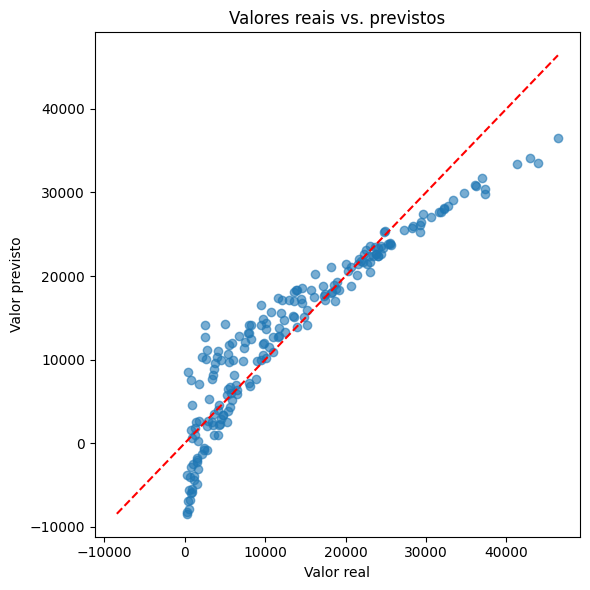

In [23]:
y_pred = model_valor.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Valores reais vs. previstos")
plt.tight_layout()
plt.show()

### Interpretacao (preditiva)
- `R2` mais alto indica melhor explicacao da variancia de `valor_total`.
- Compare `MAE` e `RMSE` com a escala de `valor_total` para julgar o erro medio.
- No grafico, pontos proximos da linha vermelha indicam previsoes mais precisas.

## Analise prescritiva (lucro)

Para estimar lucro, usamos `lucro_total = valor_total - custo_total` e ajustamos um modelo linear.

In [24]:
df["lucro_total"] = df["valor_total"] - df["custo_total"]

X = df[features]
y_lucro = df["lucro_total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_lucro, test_size=0.2, random_state=42
)

model_lucro = make_model()
model_lucro.fit(X_train, y_train)

y_pred = model_lucro.predict(X_test)

mae_lucro = mean_absolute_error(y_test, y_pred)
rmse_lucro = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lucro = r2_score(y_test, y_pred)

print(f"MAE (lucro): {mae_lucro:.2f}")
print(f"RMSE (lucro): {rmse_lucro:.2f}")
print(f"R2 (lucro): {r2_lucro:.3f}")

MAE (lucro): 1564.11
RMSE (lucro): 1948.98
R2 (lucro): 0.768


Aniversário da Loja: melhor qtd=19, preco=2494.10, lucro=12331.78


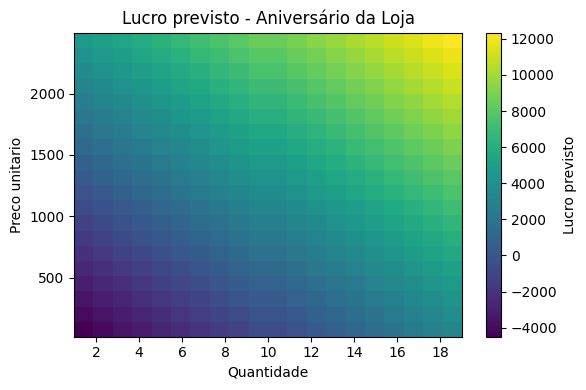

Black Friday: melhor qtd=19, preco=2494.10, lucro=12937.54


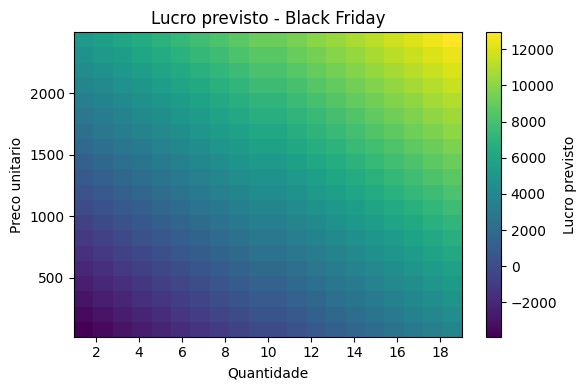

Dia das Mães: melhor qtd=19, preco=2494.10, lucro=12850.71


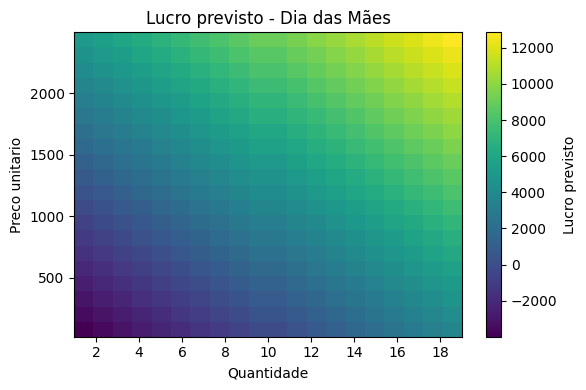

Natal: melhor qtd=19, preco=2494.10, lucro=12809.68


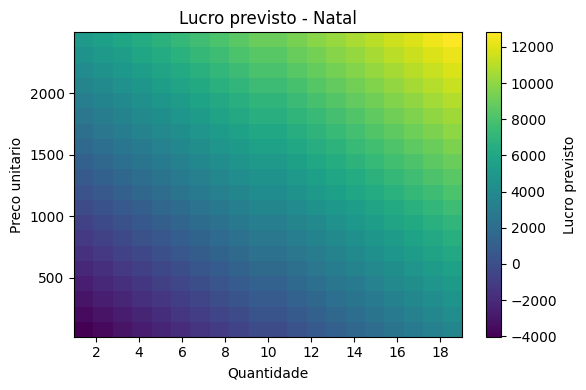

Nenhuma: melhor qtd=19, preco=2494.10, lucro=13181.78


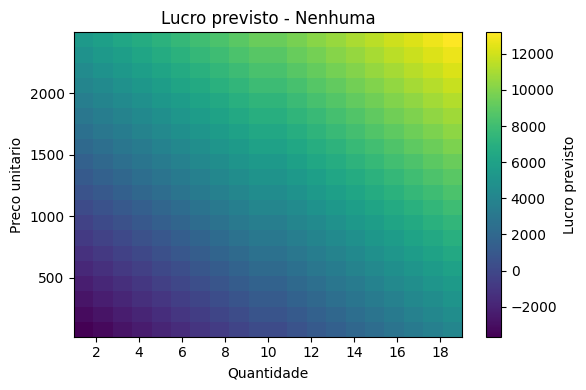

,quantidade,preco_unitario,campanha,lucro_previsto
1999,19,2494.1,Nenhuma,13181.781332
799,19,2494.1,Black Friday,12937.539893
1199,19,2494.1,Dia das Mães,12850.711313
1599,19,2494.1,Natal,12809.678933
1998,18,2494.1,Nenhuma,12750.937274


In [25]:
campaigns = sorted(df["campanha"].unique())

q_min, q_max = df["quantidade"].min(), df["quantidade"].max()
p_min, p_max = df["preco_unitario"].min(), df["preco_unitario"].max()

quant_grid = np.linspace(q_min, q_max, 20).round().astype(int)
price_grid = np.linspace(p_min, p_max, 20)

Q, P = np.meshgrid(quant_grid, price_grid)
grid_base = pd.DataFrame(
    {
        "quantidade": Q.ravel(),
        "preco_unitario": P.ravel(),
    }
)

all_results = []

for campanha in campaigns:
    grid = grid_base.copy()
    grid["campanha"] = campanha

    lucro_prev = model_lucro.predict(grid)
    grid["lucro_previsto"] = lucro_prev

    heat = lucro_prev.reshape(P.shape)
    best_idx = np.unravel_index(np.argmax(heat), heat.shape)

    best_q = Q[best_idx]
    best_p = P[best_idx]
    best_lucro = heat[best_idx]

    print(
        f"{campanha}: melhor qtd={int(best_q)}, preco={best_p:.2f}, lucro={best_lucro:.2f}"
    )

    plt.figure(figsize=(6, 4))
    plt.imshow(
        heat,
        extent=[quant_grid.min(), quant_grid.max(), price_grid.min(), price_grid.max()],
        origin="lower",
        aspect="auto",
        cmap="viridis",
    )
    plt.colorbar(label="Lucro previsto")
    plt.title(f"Lucro previsto - {campanha}")
    plt.xlabel("Quantidade")
    plt.ylabel("Preco unitario")
    plt.tight_layout()
    plt.show()

    all_results.append(grid)

all_results_df = pd.concat(all_results, ignore_index=True)
top5 = all_results_df.sort_values("lucro_previsto", ascending=False).head(5)
top5

### Recomendacoes (prescritiva)
- Use a tabela `top5` para identificar as combinacoes com maior lucro previsto.
- Compare campanhas: a que aparece com maior frequencia no topo tende a ser a mais vantajosa.
- Ajuste os limites do grid conforme estoque e demanda reais.